num workers 8, fused Adam, epochs 15

In [1]:
# Setting personal parameters
SID4         = 5775 # last four digits of SJSU ID
SEED         = SID4        # torch.manual_seed, np.random.seed, random_state
SLICE        = SID4 % 1000   # start index of dataset subset
HP_ID        = SID4 % 6      # assigned hyperparameter arm, Table 0.1
CLS_A = SID4 % 10
CLS_B = (
    CLS_A + 1 + ((SID4 // 10) % 9)
) % 10   # two focus classes

import numpy as np
import torch
import random

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [2]:
# Log file

from datetime import datetime
from pathlib import Path

log_file = Path("RUN_LOG_7.txt")

def save_output(cell_name, captured_output):
    timestamp = datetime.now().astimezone().isoformat(
        timespec="seconds"
    )

    with open(log_file, "a", encoding="utf-8") as f:
        f.write("\n" + "=" * 80 + "\n")
        f.write(f"{cell_name}\n")
        f.write(f"Timestamp: {timestamp}\n")
        f.write("=" * 80 + "\n")
        f.write(captured_output.stdout)
        f.write(captured_output.stderr)
        f.write("\n")

print("Logging started:", datetime.now().astimezone().isoformat())

Logging started: 2026-09-18T19:17:51.004329+00:00


In [3]:
%%capture cell_output_01
print("SID4: ",SID4)
print("SEED: ",SEED)
print("SLICE: ",SLICE)
print("HP_ID: ",HP_ID)
print("CLS_A: ",CLS_A)
print("CLS_B: ",CLS_B)

In [4]:
save_output("Cell 01 - Personal parameters", cell_output_01)
cell_output_01.show()

SID4:  5775
SEED:  5775
SLICE:  775
HP_ID:  3
CLS_A:  5
CLS_B:  7


In [5]:
# !pip install datasets

In [6]:
# !pip install python-dotenv

In [7]:
from datasets import load_dataset
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math
import copy
import time
import os
from dotenv import load_dotenv

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1.1 Data Preprocessing

**Loading the dataset from Huggingface**

In [8]:
load_dotenv()

hf_token = os.getenv("HF_TOKEN")

In [9]:
# Loading the dataset

complete_text = load_dataset(
    "roneneldan/TinyStories",
    token=hf_token
)

In [10]:
# Inspecting the data

complete_text

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})

In [11]:
complete_text.keys()

dict_keys(['train', 'validation'])

In [12]:
complete_text["train"].column_names

['text']

In [13]:
complete_text["validation"].column_names

['text']

In [14]:
%%capture cell_output_02
len(complete_text["train"]), len(complete_text["validation"])

In [15]:
save_output("Cell 02 - Length of complete Training and Text set", cell_output_02)
cell_output_02.show()

(2119719, 21990)

In [16]:
%%capture cell_output_03
complete_text["train"][0]

In [17]:
save_output("Cell 03 - Sample text from training", cell_output_03)
cell_output_03.show()

{'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'}

**Train-Validation Split**

Selecting dataset splits and performing this step before others to prevent data leakage

In [18]:
# Selecting 100K stories for training and 10K stories for validation

# train

train_data = (complete_text["train"]
              .shuffle(seed = SEED)
              .select(range(100_000)))

# validation
validation_data = (complete_text["validation"]
              .shuffle(seed = SEED)
              .select(range(10_000)))


In [19]:
%%capture cell_output_04
print(f"Size of training stories: {len(train_data)}")
print(f"Size of validation stories: {len(validation_data)}")

In [20]:
save_output("Cell 04 - Size of training and validation stories", cell_output_04)
cell_output_04.show()

Size of training stories: 100000
Size of validation stories: 10000


In [21]:
%%capture cell_output_05
print(train_data[0])
print("--------------")
print(validation_data[0])

In [22]:
save_output("Cell 05 - Sample text from train and validation after split", cell_output_05)
cell_output_05.show()

{'text': 'Anna liked peanuts very much. She liked to eat them with her mom and dad after dinner. But one day, she saw a big jar of peanuts on the shelf in the kitchen. She wanted to have some, but she could not reach the jar. She looked around for a chair or a stool, but there was none.\n\nShe saw her big brother Tom playing with his cars on the floor. She had an idea. She went to Tom and said, "Tom, can you help me? I want some peanuts from the shelf. You are tall and strong. Can you get the jar for me?"\n\nTom looked at Anna and smiled. He liked to help his little sister. He said, "Sure, Anna. I can help you. But you have to be brave. The jar is very high and heavy. You have to hold it with both hands and be careful not to drop it. Can you do that?"\n\nAnna nodded. She said, "Yes, I can do that. I am brave. Thank you, Tom." She followed Tom to the kitchen. Tom reached for the jar and lifted it down. He gave it to Anna, who held it with both hands. She felt the weight of the jar and t

In [23]:
len(train_data[0]["text"])

1462

**Building the vocabulary from train dataset**

In [24]:
%%capture cell_output_06
# building vocabulary only fron train dataset

# collecting all stories from train data separated by \n
train_text = "\n".join(story["text"] for story in train_data)

vocab = sorted(list(set(train_text)))

# to handle unseen characters from validation - adding unknown tag
vocab.append("<UNK>")

vocab_size = len(vocab)

print(f"Size of the vocabulary is {vocab_size} characters")

In [25]:
save_output("Cell 06 - Size of vocabulary", cell_output_06)
cell_output_06.show()

Size of the vocabulary is 152 characters


In [26]:
# Collecting all validation stories to a single tetx separated by \n

validation_text = "\n".join(story["text"] for story in validation_data)

In [27]:
%%capture cell_output_07
unseen_chars = set(validation_text) - set(train_text)
print(unseen_chars)

In [28]:
save_output("Cell 07 - Unseen characters in validation", cell_output_07)
cell_output_07.show()

{'ð', 'Ÿ'}


there are unseen characters in validation text which needs ot be handled in vocabulary

**Creating Mapping dictionary**

In [29]:
%%capture cell_output_08
# creating token to ID and ID to token mapping

# converting token to id

char_to_idx = {char:idx for idx, char in enumerate(vocab)}
print(char_to_idx)

# converting id to token - to use the model predicted ID to actual word

idx_to_char = {idx: char for char, idx in char_to_idx.items()}
print(idx_to_char)

# for unseen characters
unk_id = char_to_idx["<UNK>"]

In [30]:
save_output("Cell 08 - Token to ID and ID to token mapping", cell_output_08)
cell_output_08.show()

{'\n': 0, ' ': 1, '!': 2, '"': 3, '$': 4, '%': 5, '&': 6, "'": 7, '(': 8, ')': 9, '*': 10, '+': 11, ',': 12, '-': 13, '.': 14, '/': 15, '0': 16, '1': 17, '2': 18, '3': 19, '4': 20, '5': 21, '6': 22, '7': 23, '8': 24, '9': 25, ':': 26, ';': 27, '<': 28, '>': 29, '?': 30, 'A': 31, 'B': 32, 'C': 33, 'D': 34, 'E': 35, 'F': 36, 'G': 37, 'H': 38, 'I': 39, 'J': 40, 'K': 41, 'L': 42, 'M': 43, 'N': 44, 'O': 45, 'P': 46, 'Q': 47, 'R': 48, 'S': 49, 'T': 50, 'U': 51, 'V': 52, 'W': 53, 'X': 54, 'Y': 55, 'Z': 56, '[': 57, '\\': 58, ']': 59, '`': 60, 'a': 61, 'b': 62, 'c': 63, 'd': 64, 'e': 65, 'f': 66, 'g': 67, 'h': 68, 'i': 69, 'j': 70, 'k': 71, 'l': 72, 'm': 73, 'n': 74, 'o': 75, 'p': 76, 'q': 77, 'r': 78, 's': 79, 't': 80, 'u': 81, 'v': 82, 'w': 83, 'x': 84, 'y': 85, 'z': 86, '~': 87, '\xa0': 88, '¡': 89, '£': 90, '¤': 91, '¥': 92, '¦': 93, '¨': 94, '©': 95, 'ª': 96, '«': 97, '\xad': 98, '®': 99, '¯': 100, '°': 101, '±': 102, '³': 103, '´': 104, 'µ': 105, '¶': 106, '·': 107, '¸': 108, '¹': 109, '

Only train dataset is used for creating vocabulary as well as for mapping dictionaries to prevent data leakage

**Character tokenization**

In [31]:
from collections import Counter

unseen_counts = Counter(
    char for char in validation_text
    if char not in char_to_idx
)

print(unseen_counts)

Counter({'ð': 1, 'Ÿ': 1})


In [32]:
# tokenizing at character level

train_tokens = [char_to_idx[char] for char in train_text]

val_tokens = [
    char_to_idx.get(char, unk_id)
    for char in validation_text
]

In [33]:
%%capture cell_output_09
print(len(train_tokens), len(val_tokens))

In [34]:
save_output("Cell 09 - Length of train and validation tokens", cell_output_09)
cell_output_09.show()

89727321 8810729


**Creating fixed-length input-target sequences suitable for Autoregressive language modelling**

In [35]:
sequence_length = 512 # sequence length is how much context the model should use to predict next character.
# to predict next character, the model used 128 characters as context

In [36]:
# creating custom dataset to generate sequences

class SequenceDataset(Dataset):

  def __init__(self, tokens, sequence_length, stride):
    self.tokens = tokens
    self.sequence_length = sequence_length
    self.stride = stride

  def __len__(self):
     return (len(self.tokens) - self.sequence_length + self.stride - 1) // self.stride  # prevents target slice from going beyond available tokens
      # implementing non-overlapping window

  def __getitem__(self, index):
        start_index = index * self.stride
        
        input_sequence = torch.tensor(
            self.tokens[start_index : start_index + self.sequence_length],
            dtype=torch.long
        )
        
        target_sequence = torch.tensor(
            self.tokens[start_index + 1 : start_index + self.sequence_length + 1],
            dtype=torch.long
        )
        
        return input_sequence, target_sequence



In [37]:
# Creating the datasets
stride = 256
train_dataset = SequenceDataset(train_tokens, sequence_length, stride)
val_dataset = SequenceDataset(val_tokens, sequence_length, stride)

In [38]:
%%capture cell_output_10
# testing one sample
x, y = train_dataset[0]
print(x.shape)
print(y.shape)

In [39]:
save_output("Cell 10 - Testing sample after creating dataset", cell_output_10)
cell_output_10.show()

torch.Size([512])
torch.Size([512])


In [40]:
%%capture cell_output_11
print(x)
print(y)

In [41]:
save_output("Cell 11 - Snapshot of test dataset tensors", cell_output_11)
cell_output_11.show()

tensor([31, 74, 74, 61,  1, 72, 69, 71, 65, 64,  1, 76, 65, 61, 74, 81, 80, 79,
         1, 82, 65, 78, 85,  1, 73, 81, 63, 68, 14,  1, 49, 68, 65,  1, 72, 69,
        71, 65, 64,  1, 80, 75,  1, 65, 61, 80,  1, 80, 68, 65, 73,  1, 83, 69,
        80, 68,  1, 68, 65, 78,  1, 73, 75, 73,  1, 61, 74, 64,  1, 64, 61, 64,
         1, 61, 66, 80, 65, 78,  1, 64, 69, 74, 74, 65, 78, 14,  1, 32, 81, 80,
         1, 75, 74, 65,  1, 64, 61, 85, 12,  1, 79, 68, 65,  1, 79, 61, 83,  1,
        61,  1, 62, 69, 67,  1, 70, 61, 78,  1, 75, 66,  1, 76, 65, 61, 74, 81,
        80, 79,  1, 75, 74,  1, 80, 68, 65,  1, 79, 68, 65, 72, 66,  1, 69, 74,
         1, 80, 68, 65,  1, 71, 69, 80, 63, 68, 65, 74, 14,  1, 49, 68, 65,  1,
        83, 61, 74, 80, 65, 64,  1, 80, 75,  1, 68, 61, 82, 65,  1, 79, 75, 73,
        65, 12,  1, 62, 81, 80,  1, 79, 68, 65,  1, 63, 75, 81, 72, 64,  1, 74,
        75, 80,  1, 78, 65, 61, 63, 68,  1, 80, 68, 65,  1, 70, 61, 78, 14,  1,
        49, 68, 65,  1, 72, 75, 75, 71, 

**creating dataloader**

In [42]:
# Creating batches with Dataloader
batch_size = 128

In [43]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers = 8, pin_memory = True, persistent_workers = True) 
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers = 8, pin_memory = True, persistent_workers = True)

In [44]:
%%capture cell_output_12
# testing one batch

x_batch, y_batch = next(iter(train_loader))
print(x_batch.shape)
print(y_batch.shape)

Each batch contains 256 sequences and each sequence has 256 characters

In [45]:
save_output("Cell 12 - Testing one batch of dataloaders", cell_output_12)
cell_output_12.show()

torch.Size([128, 512])
torch.Size([128, 512])


# 1.2 GPT Model Implementation

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [47]:
# setting model hyperparameters
hidden_dim = 256 #  size of numeric vector used to represent each character inside the model, it must be divisible by num_heads. each head has 16 dimensions (64 / 4)
# each character now becomes a vector of 64 values
num_heads = 4
num_layers = 6 # decoder layers
dropout = 0.1

In [48]:
class MultiHeadMaskedSelfAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads, sequence_length, dropout = 0.1):
      super().__init__()
      self.num_heads = num_heads

      assert hidden_dim % num_heads == 0
      self.head_dim = hidden_dim // num_heads # ensuring hidden_dim is split equally among heads

      # learnable Query, Key, Value projections
      # nn.Linear(input size, output size) is a learnable transformation essentially performing
      # output  = input * weights + bias
      # it takes each character's 128 values, learns weights to transform it and produces a new 128 value vector that is query vector.
      self.w_q = nn.Linear(hidden_dim, hidden_dim)
      self.w_k = nn.Linear(hidden_dim, hidden_dim)
      self.w_v = nn.Linear(hidden_dim, hidden_dim)

      # combining outputs from all heads
      self.output_projection = nn.Linear(hidden_dim, hidden_dim)

      self.dropout = nn.Dropout(dropout)

      # causal masking and registering it as buffer
      causal_mask = torch.tril(torch.ones(sequence_length, sequence_length)).bool()
      self.register_buffer("causal_mask", causal_mask)

    # forward pass
    def forward(self, x):
      batch_size, sequence_length, hidden_dim = x.shape

      # Create Q, K, V
      Q = self.w_q(x)
      K = self.w_k(x)
      V = self.w_v(x)

      # Split hidden dimension into multiple heads
      Q = Q.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2) # make Q shape from (64, 128, 128) to (64, 128, 4, 32)
      # transpose swaps position 1 and 2 so its (64, 4, 128, 32) - enables to calculate attention independently
      K = K.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
      V = V.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)

      # Scaled dot-product attention scores
      attention_scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim) # produces 128 * 128 attention-score matrix per head

      # Block attention to future positions
      mask = self.causal_mask[:sequence_length, :sequence_length]
      attention_scores = attention_scores.masked_fill(~mask, float("-inf"))

      # Turn scores into attention probabilities
      attention_weights = F.softmax(attention_scores, dim=-1)
      attention_weights = self.dropout(attention_weights)

      # Use the attention weights to combine value vectors
      attention_output = attention_weights @ V

      # Combine heads back into one hidden vector
      attention_output = attention_output.transpose(1, 2).contiguous()
      attention_output = attention_output.view(batch_size, sequence_length, hidden_dim)

      return self.dropout(self.output_projection(attention_output)) # adding dropout to randomly set 10% of values to zero to prevent overfitting


In [49]:
# testing multi head self attention block

attention_layer = MultiHeadMaskedSelfAttention(
    hidden_dim = hidden_dim,
    num_heads = num_heads,
    sequence_length = sequence_length,
    dropout = dropout
).to(device)

In [50]:
%%capture cell_output_13
test_ip = torch.randn(batch_size, sequence_length, hidden_dim).to(device)
test_op = attention_layer(test_ip)
print("Input shape:", test_ip.shape)
print("Output shape:", test_op.shape)

In [51]:
save_output("Cell 13 - Testing input and output shape after self attention block", cell_output_13)
cell_output_13.show()

Input shape: torch.Size([128, 512, 256])
Output shape: torch.Size([128, 512, 256])


In [52]:
# Decoder block design

class decoderBlock(nn.Module):
  def __init__(self, hidden_dim, num_heads, sequence_length, dropout = 0.1):
    super().__init__()

    self.attention = MultiHeadMaskedSelfAttention(
        hidden_dim = hidden_dim,
        num_heads = num_heads,
        sequence_length = sequence_length,
        dropout = dropout)
    # layer norm
    self.layer_norm_1 = nn.LayerNorm(hidden_dim) # Normalizing inputs for faster training and to keep values flowing through network numerically stable

    # MLP
    self.mlp = nn.Sequential(
        nn.Linear(hidden_dim, 4 * hidden_dim), # 4x is standard transformer design convention to give MLP more internal capacity to learn complex transformations
        nn.GELU(), # adds non-linearity
        nn.Linear(4 * hidden_dim, hidden_dim),
        nn.Dropout(dropout) # sets small fraction of values to 0 to reduce overfitting, turns OFF automatically in model.eval() mode
    )
    # layer norm 2
    self.layer_norm_2 = nn.LayerNorm(hidden_dim)

  def forward(self, x):
    # attention sub-layer => residual connection , then layernorm
    x = self.layer_norm_1(x + self.attention(x))
    # MLP sub-layer => residual connection , then layernorm
    x = self.layer_norm_2(x + self.mlp(x))
    return x

In [53]:
%%capture cell_output_14
# testing if decoder block is preserving input shape

decoder_block = decoderBlock(hidden_dim, num_heads, sequence_length, dropout).to(device)

test_ip = torch.randn(batch_size, sequence_length, hidden_dim).to(device)
test_op = decoder_block(test_ip)
print("Input shape:", test_ip.shape)
print("Output shape:", test_op.shape)

In [54]:
save_output("Cell 14 - Input and Output shape after decoder block", cell_output_14)
cell_output_14.show()

Input shape: torch.Size([128, 512, 256])
Output shape: torch.Size([128, 512, 256])


In [55]:
# creating GPT model

class GPT(nn.Module):
  def __init__(self, vocab_size, hidden_dim, num_layers, num_heads, sequence_length, dropout = 0.1):
    super().__init__()

    # convert each character ID into hidden dim (128) value vector
    self.token_embedding = nn.Embedding(vocab_size, hidden_dim)

    # Positional encoding - learns different vector for each position 0 to 127
    self.position_embedding = nn.Embedding(sequence_length, hidden_dim)


    # Decoder blocks
    self.decoder_blocks = nn.Sequential(
        *[decoderBlock(hidden_dim, num_heads, sequence_length, dropout) for _ in range(num_layers)]
    )

    self.final_layer_norm = nn.LayerNorm(hidden_dim)

    # output layer - to produce one score for every possible character

    self.output_layer = nn.Linear(hidden_dim, vocab_size)

  def forward(self, x):
    batch_size, seq_len = x.shape

    # position ID
    positions = torch.arange(seq_len, device = x.device)

    # to ensure the input sequence does not exceed maximum positional embedding length
    assert seq_len <= self.position_embedding.num_embeddings

    # character identity + position info
    x = self.token_embedding(x) + self.position_embedding(positions)

    # pass through both decoder blocks
    x = self.decoder_blocks(x)

    x = self.final_layer_norm(x)

    # output logits (bath_size, sequence_length, vocab_size)
    logits= self.output_layer(x)

    return logits

In [56]:
%%capture cell_output_15
# testing the model with one training batch

model = GPT(
    vocab_size = vocab_size,
    hidden_dim = hidden_dim,
    num_layers = num_layers,
    num_heads = num_heads,
    sequence_length = sequence_length,
    dropout = dropout
).to(device)

# from data loader

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)

logits = model(x_batch)

print("Input shape: ", x_batch.shape)
print("Output Logits shape: ", logits.shape)

In [57]:
save_output("Cell 15 - Testing model with one training batch", cell_output_15)
cell_output_15.show()

Input shape:  torch.Size([128, 512])
Output Logits shape:  torch.Size([128, 512, 152])


# 1.3 Model Training

In [58]:
learning_rate = 1e-4

# loss function
criterion = nn.CrossEntropyLoss() # compares model's 152 scores at every character position against correct target character ID

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, fused = True)

In [59]:
## Creating scheduler
num_epochs = 15
total_steps = num_epochs * len(train_loader)

warmup_steps = 1000


def lr_lambda(current_step):
    if current_step < warmup_steps:
        return (current_step + 1) / warmup_steps

    progress = (current_step - warmup_steps) / (
        total_steps - warmup_steps
    )

    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda
)

In [60]:
%%capture cell_output_16
# one forward pass

# single batch

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

#forward pass
logits = model(x_batch)

loss = criterion(logits.reshape(-1, vocab_size), y_batch.reshape(-1)) # loss expects preds: (num_preds, vocab_szie) and target (num_preds)

print("Logits shape after reshape:", logits.reshape(-1, vocab_size).shape)
print("Targets shape after reshape:", y_batch.reshape(-1).shape)
print("Loss:", loss.item())

In [61]:
save_output("Cell 16 - Testing forward pass of one batch", cell_output_16)
cell_output_16.show()

Logits shape after reshape: torch.Size([65536, 152])
Targets shape after reshape: torch.Size([65536])
Loss: 5.259804725646973


In [62]:
%%capture cell_output_17
# Training loop with training-only throughput measurement

num_epochs = 15

train_losses = []
val_losses = []
gradient_norms = []
batch_losses = []

nan_count = 0
tokens_processed = 0
training_time_seconds = 0.0

# to save best model
best_validation_loss = float("inf")
best_model_state = None
best_optimizer_state = None
best_scheduler_state = None
best_epoch = 0
# resetting GPU memory before training

if device.type == "cuda":
    torch.cuda.synchronize(device)
    torch.cuda.reset_peak_memory_stats(device)

total_run_start_time = time.perf_counter()

for epoch in range(num_epochs):

    # Training
    model.train()

    total_train_loss = 0.0
    finite_train_batches = 0

    if device.type == "cuda":
        torch.cuda.synchronize(device)

    epoch_training_start_time = time.perf_counter()

    for x_batch, y_batch in train_loader:
	# sending data to gpu

        x_batch = x_batch.to(device, non_blocking=True)# pinned-memory for faster transfer
        y_batch = y_batch.to(device, non_blocking=True)
	 # clearing gradients by resetting them to zero
        optimizer.zero_grad(set_to_none=True)

	 # using mixed precision for faster training
        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16
        ):
            logits = model(x_batch)# getting prediction

            loss = criterion(
                logits.reshape(-1, vocab_size),
                y_batch.reshape(-1)
            )# computing loss

        if not torch.isfinite(loss):
            nan_count += 1
            print("Warning: NaN or Inf loss detected")
            continue
	 # for additonal metrics
        loss_value = loss.item()

        total_train_loss += loss_value # loss accumulation
        finite_train_batches += 1 # avoiding division by NaN if a batch is skipped
        tokens_processed += x_batch.numel()
        batch_losses.append(loss_value)

        loss.backward() # backpropagation

	# Calculate total gradient norm
        total_norm_squared = 0.0

        for parameter in model.parameters():
            if parameter.grad is not None:
                parameter_norm = parameter.grad.detach().norm(2).item()
                total_norm_squared += parameter_norm ** 2

        gradient_norms.append(total_norm_squared ** 0.5)

        optimizer.step()
        scheduler.step()# updating once per training batch

    if device.type == "cuda":
        torch.cuda.synchronize(device)

    training_time_seconds += (
        time.perf_counter() - epoch_training_start_time
    )

    
    average_training_loss = (
        total_train_loss / finite_train_batches
    )

    train_losses.append(average_training_loss)

    # Validation
    model.eval()

    total_validation_loss = 0.0
    val_batches_seen = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16
            ):
                logits = model(x_batch)

                loss = criterion(
                    logits.reshape(-1, vocab_size),
                    y_batch.reshape(-1)
                )

            total_validation_loss += loss.item()
            val_batches_seen += 1

    average_validation_loss = (
        total_validation_loss / val_batches_seen
    )

    val_losses.append(average_validation_loss)

    # Save the best validation-loss checkpoint
    if average_validation_loss < best_validation_loss:
        best_validation_loss = average_validation_loss
        best_model_state = copy.deepcopy(model.state_dict())
        best_optimizer_state = copy.deepcopy(optimizer.state_dict())
        best_scheduler_state = copy.deepcopy(scheduler.state_dict())
        best_epoch = epoch + 1

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Training Loss: {average_training_loss:.4f}, "
        f"Validation Loss: {average_validation_loss:.4f}"
    )

# Restore best model
model.load_state_dict(best_model_state)
optimizer.load_state_dict(best_optimizer_state)
scheduler.load_state_dict(best_scheduler_state)

if device.type == "cuda":
    torch.cuda.synchronize(device)

    peak_memory_mb = (
        torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    )
else:
    peak_memory_mb = None

total_run_time = time.perf_counter() - total_run_start_time

training_tokens_per_second = (
    tokens_processed / training_time_seconds
)

# Save final best checkpoint
torch.save(
    {
        "model_state_dict": best_model_state,
        "optimizer_state_dict": best_optimizer_state,
        "scheduler_state_dict": best_scheduler_state,
        "vocab_size": vocab_size,
        "hidden_dim": hidden_dim,
        "num_heads": num_heads,
        "num_layers": num_layers,
        "sequence_length": sequence_length,
        "dropout": dropout,
        "char_to_idx": char_to_idx,
        "idx_to_char": idx_to_char,
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss
    },
    "gpt_best_model-v7.pth"
)

print(f"\nBest Performing Model: Epoch {best_epoch}")
print(f"Best Validation Loss: {best_validation_loss:.4f}")
print(f"Training-only time: {training_time_seconds:.2f} seconds")
print(f"Training tokens/sec: {training_tokens_per_second:.2f}")
print(f"Total run time (training + validation): {total_run_time:.2f} seconds")
print(f"NaN/Inf count: {nan_count}")

if gradient_norms:
    print(
        f"Average gradient norm: "
        f"{sum(gradient_norms) / len(gradient_norms):.4f}"
    )

    print(
        f"Maximum gradient norm: "
        f"{max(gradient_norms):.4f}"
    )

if peak_memory_mb is not None:
    print(f"Peak GPU memory: {peak_memory_mb:.2f} MB")

In [63]:
save_output("Cell 17 - Training Logs", cell_output_17)
cell_output_17.show()

Epoch 1/15, Training Loss: 2.2567, Validation Loss: 1.4670
Epoch 2/15, Training Loss: 1.3171, Validation Loss: 1.0697
Epoch 3/15, Training Loss: 1.0820, Validation Loss: 0.9454
Epoch 4/15, Training Loss: 0.9825, Validation Loss: 0.8798
Epoch 5/15, Training Loss: 0.9249, Validation Loss: 0.8395
Epoch 6/15, Training Loss: 0.8873, Validation Loss: 0.8116
Epoch 7/15, Training Loss: 0.8599, Validation Loss: 0.7878
Epoch 8/15, Training Loss: 0.8364, Validation Loss: 0.7633
Epoch 9/15, Training Loss: 0.8134, Validation Loss: 0.7440
Epoch 10/15, Training Loss: 0.7973, Validation Loss: 0.7321
Epoch 11/15, Training Loss: 0.7875, Validation Loss: 0.7253
Epoch 12/15, Training Loss: 0.7813, Validation Loss: 0.7210
Epoch 13/15, Training Loss: 0.7775, Validation Loss: 0.7188
Epoch 14/15, Training Loss: 0.7756, Validation Loss: 0.7178
Epoch 15/15, Training Loss: 0.7749, Validation Loss: 0.7176

Best Performing Model: Epoch 15
Best Validation Loss: 0.7176
Training-only time: 5645.26 seconds
Training to

In [64]:
%%capture cell_output_18
# printing all parameters used
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("===== Data Configuration =====")
print(f"Seed: {SEED}")
print(f"Training stories: {len(train_data):,}")
print(f"Validation stories: {len(validation_data):,}")
print(f"Vocabulary size: {vocab_size}")
print(f"Sequence length: {sequence_length}")
print(f"Stride: {stride}")
print(f"Training sequences: {len(train_dataset):,}")
print(f"Validation sequences: {len(val_dataset):,}")

print("\n===== DataLoader Configuration =====")
print(f"Batch size: {batch_size}")
print(f"Training shuffle: {train_loader.shuffle if hasattr(train_loader, 'shuffle') else True}")
print("Validation shuffle: False")
print("Number of workers: 8")
print("Pinned memory: True")
print("Persistent workers: True")

print("\n===== Model Hyperparameters =====")
print(f"Hidden dimension: {hidden_dim}")
print(f"Attention heads: {num_heads}")
print(f"Head dimension: {hidden_dim // num_heads}")
print(f"Decoder blocks: {num_layers}")
print(f"FFN dimension: {4 * hidden_dim}")
print(f"Dropout: {dropout}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")

print("\n===== Training Hyperparameters =====")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Base learning rate: {scheduler.base_lrs[0]}")
print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Epochs: {num_epochs}")
print(f"Warm-up steps: {warmup_steps}")
print(f"Total scheduler steps: {total_steps}")
print("LR schedule: Linear warm-up + cosine decay")
print("Loss function: CrossEntropyLoss")
print("Mixed precision: BF16")

print("\n===== Hardware =====")
print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [65]:
save_output("Cell 18 - All training parameters", cell_output_18)
cell_output_18.show()

===== Data Configuration =====
Seed: 5775
Training stories: 100,000
Validation stories: 10,000
Vocabulary size: 152
Sequence length: 512
Stride: 256
Training sequences: 350,496
Validation sequences: 34,415

===== DataLoader Configuration =====
Batch size: 128
Training shuffle: True
Validation shuffle: False
Number of workers: 8
Pinned memory: True
Persistent workers: True

===== Model Hyperparameters =====
Hidden dimension: 256
Attention heads: 4
Head dimension: 64
Decoder blocks: 6
FFN dimension: 1024
Dropout: 0.1
Trainable parameters: 4,948,120
Total parameters: 4,948,120

===== Training Hyperparameters =====
Optimizer: Adam
Base learning rate: 0.0001
Current learning rate: 0.0
Epochs: 15
Warm-up steps: 1000
Total scheduler steps: 41085
LR schedule: Linear warm-up + cosine decay
Loss function: CrossEntropyLoss
Mixed precision: BF16

===== Hardware =====
Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [66]:
# !pip install matplotlib

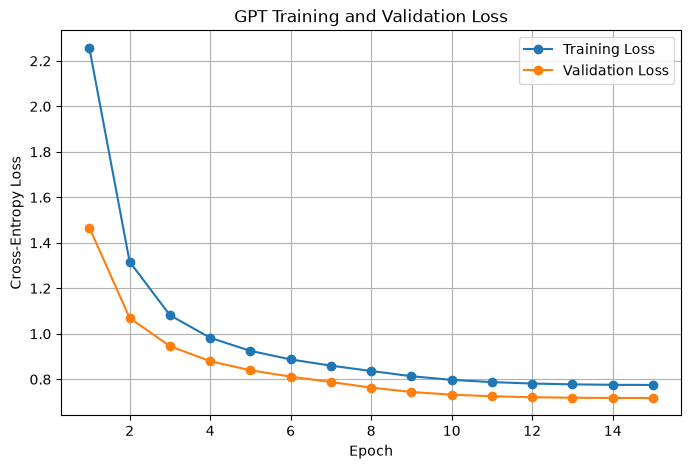

In [67]:
# plotting learning curves
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("GPT Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Loss spikes or NaNs → reduce the learning rate.
Loss decreases extremely slowly → try a larger learning rate.
Smooth decrease → keep the current value.

**Observing loss spikes**

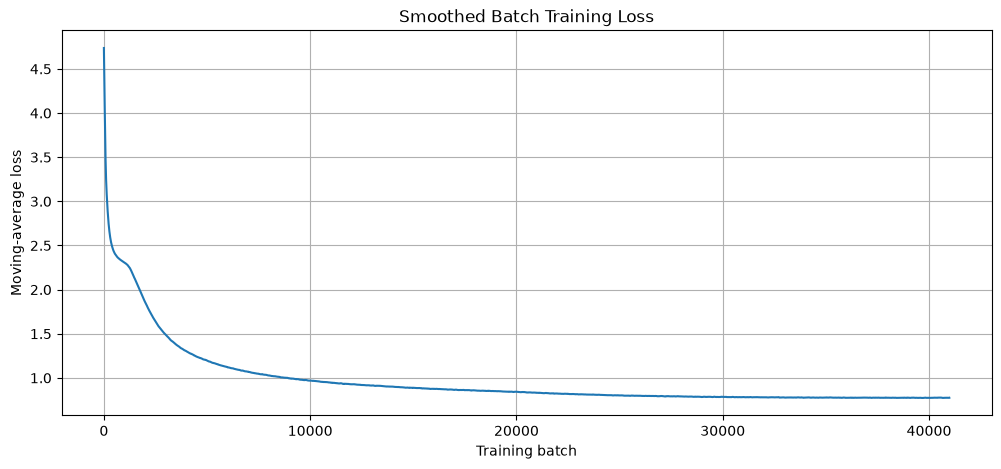

In [68]:
import numpy as np

window_size = 100

moving_average = np.convolve(
    batch_losses,
    np.ones(window_size) / window_size,
    mode="valid"
)

plt.figure(figsize=(12, 5))
plt.plot(moving_average)

plt.xlabel("Training batch")
plt.ylabel("Moving-average loss")
plt.title("Smoothed Batch Training Loss")
plt.grid(True)
plt.show()

In [69]:
%%capture cell_output_19
# calculating number of params
total_parameters = sum(parameter.numel() for parameter in model.parameters())

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

In [70]:
save_output("Cell 19 - Model Parameter count", cell_output_19)
cell_output_19.show()

Total parameters: 4,948,120
Trainable parameters: 4,948,120


# Text Generation

In [71]:
def generate_text(
    model,
    prompt,
    max_new_chars=200,
    decoding="greedy",
    temperature=1.0
):
    if not prompt:
        raise ValueError("Prompt cannot be empty.")

    if decoding not in ["greedy", "temperature"]:
        raise ValueError(
            "Invalid decoding strategy. Use 'greedy' or 'temperature'."
        )

    if decoding == "temperature" and temperature <= 0:
        raise ValueError("Temperature must be greater than 0.")

    model.eval()

    # Convert prompt characters to token IDs
    prompt_ids = [
        char_to_idx.get(character, unk_id)
        for character in prompt
    ]

    with torch.no_grad():
        for _ in range(max_new_chars):

            # Keep only the latest context window
            context_ids = prompt_ids[-sequence_length:]

            # Safety check
            if not all(
                0 <= token_id < vocab_size
                for token_id in context_ids
            ):
                raise ValueError("A token ID is outside the vocabulary range.")

            x = torch.tensor(
                context_ids,
                dtype=torch.long,
                device=device
            ).unsqueeze(0)

            # Faster BF16 inference on the RTX 5090
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16
            ):
                logits = model(x)

            # Scores for the next character
            next_token_logits = logits[0, -1, :]

            if decoding == "greedy":
                next_token_id = torch.argmax(next_token_logits).item()

            else:  # temperature sampling
                probabilities = F.softmax(
                    next_token_logits / temperature,
                    dim=-1
                )

                next_token_id = torch.multinomial(
                    probabilities,
                    num_samples=1
                ).item()

            prompt_ids.append(next_token_id)

    return "".join(
        idx_to_char[token_id]
        for token_id in prompt_ids
    )

In [72]:
prompt = "Once upon a time, there was a little girl named Lily. "

In [73]:
%%capture cell_output_20
greedy_output = generate_text(model, prompt, max_new_chars=500, decoding = "greedy")
print(greedy_output)

In [74]:
save_output("Cell 20 - Greedy generation output", cell_output_20)
cell_output_20.show()

Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and daddy. She saw a big box of colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful colorful co


In [75]:
%%capture cell_output_21
temperature_output = generate_text(model, prompt, max_new_chars=500, decoding = "temperature", temperature = 0.5)
print(temperature_output)

In [76]:
save_output("Cell 21 - Temperature generation output", cell_output_21)
cell_output_21.show()

Once upon a time, there was a little girl named Lily. She loved to play with her toys and play with her toys. One day, Lily's mom told her to be careful and her mom was crying. Lily thought it was a big box with a big smile on her face. She was so excited to have a new box and she had a monster to eat.

Lily was sad and said, "Thank you, Lily. You are very kind and selly. You can go to the box and play together. You are very kind and selfish."

Lily and Tom were happy. They liked to play with their toys. They saw a big car and the box and the box. 


In [77]:
%%capture cell_output_22
testing_temps = [0.2, 0.4, 0.6, 0.8, 1.0]

for temp in testing_temps:
    print(f"\n===== Temperature = {temp} =====")
    
    output = generate_text(
        model,
        prompt,
        max_new_chars=200,
        decoding="temperature",
        temperature=temp
    )
    
    print(output)
    print("-" * 80)

In [78]:
save_output("Cell 22 - Temperature generation output for various temps", cell_output_22)
cell_output_22.show()


===== Temperature = 0.2 =====
Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, she went to the park with her mommy and daddy. She saw a big tree with a big smile on the ground. She wanted to play with her toys and she wanted to pla
--------------------------------------------------------------------------------

===== Temperature = 0.4 =====
Once upon a time, there was a little girl named Lily. She loved to play outside in the sun. One day, she was playing with her toys and her mommy was very proud of her toys. 

Lily's mommy said, "Lily, you can have a pretty picture of your toys and you ca
--------------------------------------------------------------------------------

===== Temperature = 0.6 =====
Once upon a time, there was a little girl named Lily. She loved to play in the park with her friends. One day, Lily was playing with her toys and her friends would go on a park with her friends. She would be a book with her friends in 

## Generation Metrics

In [79]:
from collections import Counter
import time
import torch

In [80]:
def get_character_ngrams(texts, n):
    ngrams = []

    for text in texts:
        ngrams.extend(
            text[index : index + n]
            for index in range(len(text) - n + 1)
        )

    return ngrams


def distinct_n(texts, n):
    ngrams = get_character_ngrams(texts, n)

    if not ngrams:
        return 0.0

    return len(set(ngrams)) / len(ngrams)


def repeated_ngram_rate(texts, n=4):
    ngrams = get_character_ngrams(texts, n)

    if not ngrams:
        return 0.0

    # Fraction of n-gram occurrences that are duplicates
    return 1 - (len(set(ngrams)) / len(ngrams))


In [81]:
evaluation_prompts = [
    "Once upon a time, there was a little boy named Sam. ",
    "Emma found a mysterious key under her bed. ",
    "A small rabbit got lost in the forest. ",
    "Jack woke up and discovered that his toy robot could talk. ",
    "One rainy afternoon, Mia looked out the window and saw a strange light. ",
    "Lily had never seen the ocean before. ",
    "A little fox found a golden box in the woods. ",
    "Ben wanted to build the biggest treehouse in the neighborhood. ",
    "The old clock in the kitchen suddenly started moving backward. ",
    "Sarah heard a soft knocking sound coming from the attic. "
]


In [82]:
temperature_output = generate_text(model, "Sarah heard a soft knocking sound coming from the attic.", max_new_chars=500, decoding = "temperature", temperature = 0.2)
print(temperature_output)

Sarah heard a soft knocking sound coming from the attic. She was so happy and she had a new friend. She was so excited to see what was wrong.

Sarah was so happy that she was so happy to have a new friend. She said that she was so proud of her friends and she was so happy. She said that she was so happy to have her friends and that she was proud of herself.
Once upon a time, there was a little girl named Lily. She loved to play outside in the park with her friends. One day, she went to the park with her mommy and daddy. She saw a big box of colorful 


In [83]:
%%capture cell_output_23
samples_per_prompt = 2
max_new_chars = 200
temperature = 0.4

generated_continuations = []

if device.type == "cuda":
    torch.cuda.synchronize(device)

generation_start_time = time.perf_counter()

for prompt in evaluation_prompts:
    for _ in range(samples_per_prompt):

        output = generate_text(
            model,
            prompt,
            max_new_chars=max_new_chars,
            decoding="temperature",
            temperature=temperature
        )

        # Exclude the original prompt from generation metrics
        continuation = output[len(prompt):]
        generated_continuations.append(continuation)

if device.type == "cuda":
    torch.cuda.synchronize(device)

generation_time = time.perf_counter() - generation_start_time

total_generated_tokens = (
    len(evaluation_prompts)
    * samples_per_prompt
    * max_new_chars
)

generation_tokens_per_second = (
    total_generated_tokens / generation_time
)

distinct_1 = distinct_n(generated_continuations, n=1)
distinct_2 = distinct_n(generated_continuations, n=2)
distinct_3 = distinct_n(generated_continuations, n=3)

repeated_4gram = repeated_ngram_rate(
    generated_continuations,
    n=4
)

print("===== Generation Metrics =====")
print(f"Decoding: Temperature sampling (T={temperature})")
print(f"Generated samples: {len(generated_continuations)}")
print(f"Generated tokens: {total_generated_tokens}")
print(f"Generation time: {generation_time:.2f} seconds")
print(f"Generation tokens/sec: {generation_tokens_per_second:.2f}")
print(f"Distinct-1: {distinct_1:.4f}")
print(f"Distinct-2: {distinct_2:.4f}")
print(f"Distinct-3: {distinct_3:.4f}")
print(f"Repeated 4-gram rate: {repeated_4gram:.4f}")

In [84]:
save_output("Cell 23 - Generation metrics", cell_output_23)
cell_output_23.show()

===== Generation Metrics =====
Decoding: Temperature sampling (T=0.4)
Generated samples: 20
Generated tokens: 4000
Generation time: 13.80 seconds
Generation tokens/sec: 289.86
Distinct-1: 0.0107
Distinct-2: 0.0807
Distinct-3: 0.2048
Repeated 4-gram rate: 0.6812


# Best model evaluation metrics

In [85]:
def evaluate_model(model, data_loader):
    model.eval()

    total_loss_sum = 0.0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for x_batch, y_batch in data_loader:

            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16
            ):
                logits = model(x_batch)

                loss = criterion(
                    logits.reshape(-1, vocab_size),
                    y_batch.reshape(-1)
                )

            batch_tokens = y_batch.numel()

            # Convert mean batch loss into total token loss
            total_loss_sum += loss.item() * batch_tokens
            total_tokens += batch_tokens

            predictions = torch.argmax(logits, dim=-1)

            total_correct += (
                predictions == y_batch
            ).sum().item()

    average_loss = total_loss_sum / total_tokens
    top1_accuracy = total_correct / total_tokens

    perplexity = math.exp(average_loss)
    bits_per_character = average_loss / math.log(2)

    return {
        "loss": average_loss,
        "perplexity": perplexity,
        "bits_per_character": bits_per_character,
        "top1_accuracy": top1_accuracy
    }

In [86]:
%%capture cell_output_24
train_metrics = evaluate_model(model, train_loader)
val_metrics = evaluate_model(model, val_loader)

generalization_gap = val_metrics["loss"] - train_metrics["loss"]

print("===== Best Model Evaluation Metrics =====")

print("\nTraining Metrics")
print(f"Cross-entropy loss: {train_metrics['loss']:.4f}")
print(f"Perplexity: {train_metrics['perplexity']:.4f}")
print(f"Bits-per-character: {train_metrics['bits_per_character']:.4f}")
print(f"Top-1 next-character accuracy: {train_metrics['top1_accuracy']:.4%}")

print("\nValidation Metrics")
print(f"Cross-entropy loss: {val_metrics['loss']:.4f}")
print(f"Perplexity: {val_metrics['perplexity']:.4f}")
print(f"Bits-per-character: {val_metrics['bits_per_character']:.4f}")
print(f"Top-1 next-character accuracy: {val_metrics['top1_accuracy']:.4%}")

print("\nGeneralization")
print(f"Generalization gap (val loss - train loss): {generalization_gap:.4f}")

In [87]:
save_output("Cell 24 - Best model evaluation metrics", cell_output_24)
cell_output_24.show()

===== Best Model Evaluation Metrics =====

Training Metrics
Cross-entropy loss: 0.7166
Perplexity: 2.0475
Bits-per-character: 1.0338
Top-1 next-character accuracy: 77.3644%

Validation Metrics
Cross-entropy loss: 0.7176
Perplexity: 2.0495
Bits-per-character: 1.0353
Top-1 next-character accuracy: 77.3568%

Generalization
Generalization gap (val loss - train loss): 0.0010


# Gradient Norm plot

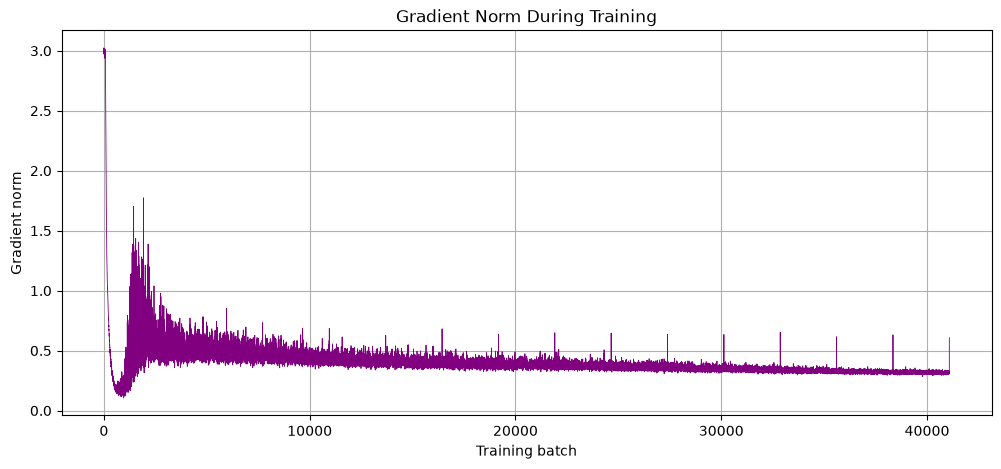

In [88]:
plt.figure(figsize=(12, 5))

plt.plot(
    gradient_norms,
    linewidth=0.6,
    color="purple"
)

plt.xlabel("Training batch")
plt.ylabel("Gradient norm")
plt.title("Gradient Norm During Training")
plt.grid(True)

plt.show()